# Visualization

Two complementary views of a model, both reading from the same training run:

- **Plotting** (`PlotVisualizer`) — how *values* evolve over training: loss, accuracy, and the distributions of weights and gradients.
- **Graphing** (`GraphVisualizer`) — the *structure* of a single forward/backward pass: the computation graph, the same graph with layers boxed, and the collapsed architecture.

## Setup

Train a small classifier on a synthetic 3-class dataset, recording history as we go. The `Recorder` collects two kinds of data: scalars handed in each step (`loss`, `acc`), and the parameters/activations harvested from the graph by `capture()` after each `backward()`.

In [ ]:
%matplotlib inline

from random import Random

from babygrad.metrics import Accuracy
from babygrad.nn.activations import ReLU, Sigmoid, Softmax
from babygrad.nn.initializers import Glorot, Uniform
from babygrad.nn.losses import CCE
from babygrad.nn.model import Model
from babygrad.nn.modules import BatchNorm, Linear, Sequential
from babygrad.nn.optimizers import SGD
from babygrad.observers import Recorder, Tracer
from babygrad.tensor import Tensor
from babygrad.tracing import tracing
from babygrad.viz.attribution import attribute
from babygrad.viz.graph import GraphVisualizer
from babygrad.viz.plot import PlotVisualizer
from babygrad.types import NodeKind

In [ ]:
# synthetic data: each class has its features shifted around a different mean
rng = Random(0)
samples = 24
features, targets = [], []
for i in range(samples):
    label = i % 3
    features.extend(rng.gauss(label, 0.5) for _ in range(4))
    onehot = [0.0, 0.0, 0.0]
    onehot[label] = 1.0
    targets.extend(onehot)

x = Tensor(features, shape=(samples, 4), kind=NodeKind.INPUT)
y = Tensor(targets, shape=(samples, 3), kind=NodeKind.TARGET)

net = Sequential([Linear(4, 16), ReLU(), Linear(16, 3), Softmax()])
model = Model(net)
optimizer = SGD(net.parameters())
optimizer.lr = 0.3
criterion = CCE()
recorder = Recorder()

for step in range(40):
    recorder.step = step
    optimizer.zero_grad()
    # trace the forward so the recorder can harvest this step's params/activations
    tracer = Tracer()
    with tracing(tracer):
        y_pred = model.forward(x)
        loss = criterion(y, y_pred)
    recorder.record("loss", loss.data[0])
    recorder.record("acc", Accuracy().compute(y, y_pred))
    loss.backward()
    recorder.capture(tracer)
    optimizer.step()

round(recorder.history["loss"][0], 4), round(recorder.history["loss"][39], 4)

## Plotting training history

`PlotVisualizer` is constructed with the recorded history and renders it post-hoc. It never touches the model — it only consumes the plain `tag -> step -> value` data the `Recorder` collected.

### Loss and accuracy over steps

Scalar series, one value per step.

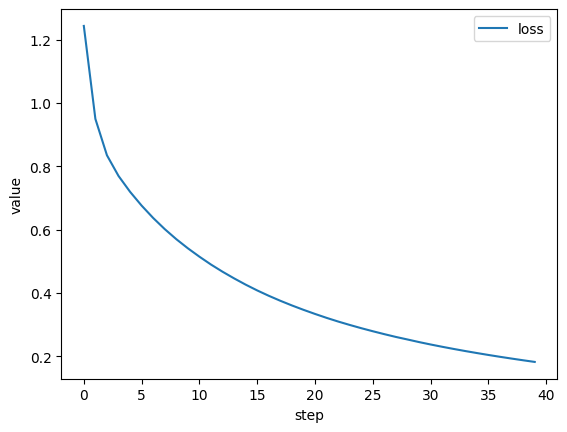

In [3]:
viz = PlotVisualizer(recorder.history)
viz.plot_scalar(["loss"])

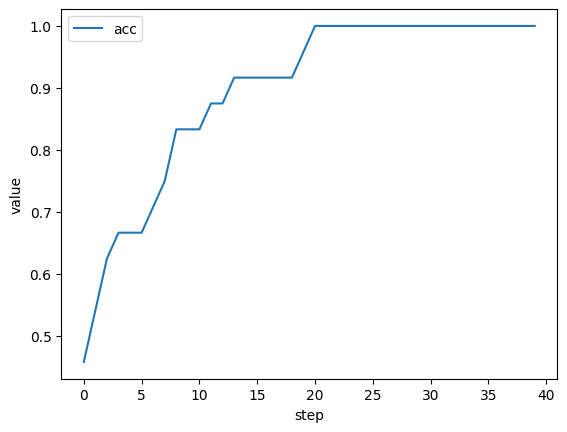

In [4]:
viz.plot_scalar(["acc"])

### Weight and gradient distributions

A *ridge* plot stacks one histogram per step (earliest at the bottom), so you can watch a distribution drift as training proceeds. Gradients are heavy-tailed, so we clip the bins to the 1st-99th percentile and let outliers pile into the edge bins.

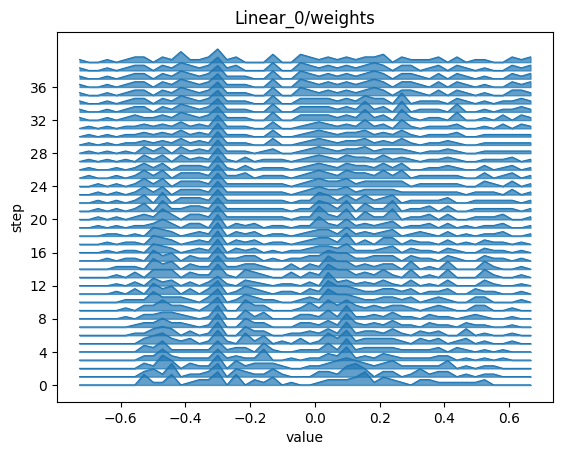

In [5]:
viz.plot_ridge("Linear_0/weights")

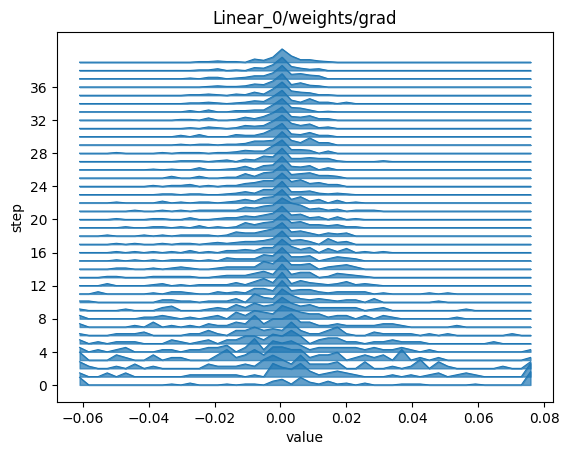

In [6]:
viz.plot_ridge("Linear_0/weights/grad", clip_quantiles=(0.01, 0.99))

## Graphing the network

`GraphVisualizer` walks the autograd graph backward from a tensor (here, the loss) into a neutral bipartite structure — tensors and ops are both nodes — then draws it. We build it from a fresh forward pass so the graph reflects the trained weights.

In [ ]:
# Trace the forward pass so the graph knows which scope each node belongs to.
tracer = Tracer()
with tracing(tracer):
    y_pred = model.forward(x)
    loss = criterion(y, y_pred)
graph = GraphVisualizer(loss, attribute(tracer.records))

### Computation graph

Every operation is its own node (red ellipse) sitting between its input and output tensors (boxes). Dashed edges feed *into* an op; solid edges carry its result out. Node colours encode role: input/target (amber), parameters (cyan), op results (grey), layer outputs (blue), loss (navy).

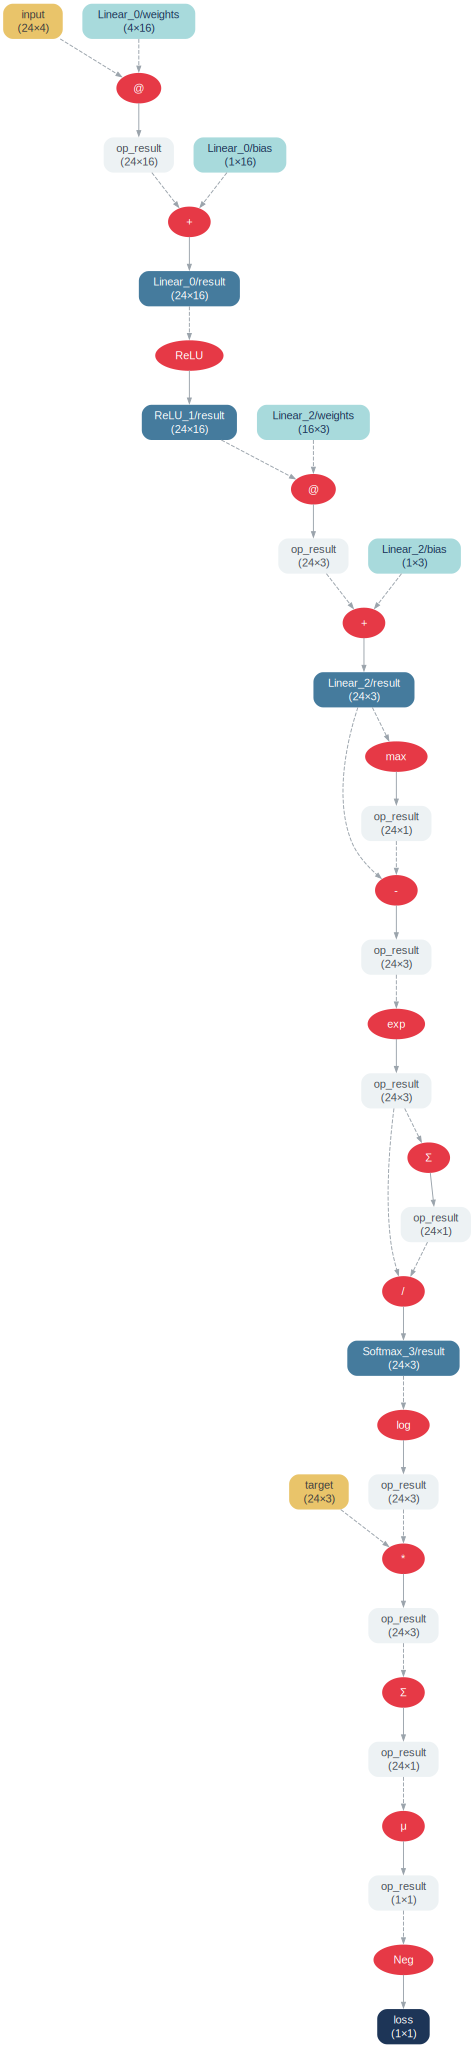

In [8]:
graph.draw_computation()

### Combined

The same graph, with every layer's nodes wrapped in a titled cluster box (its scope). Input and target sit outside the boxes — they enter the computation rather than belonging to any layer.

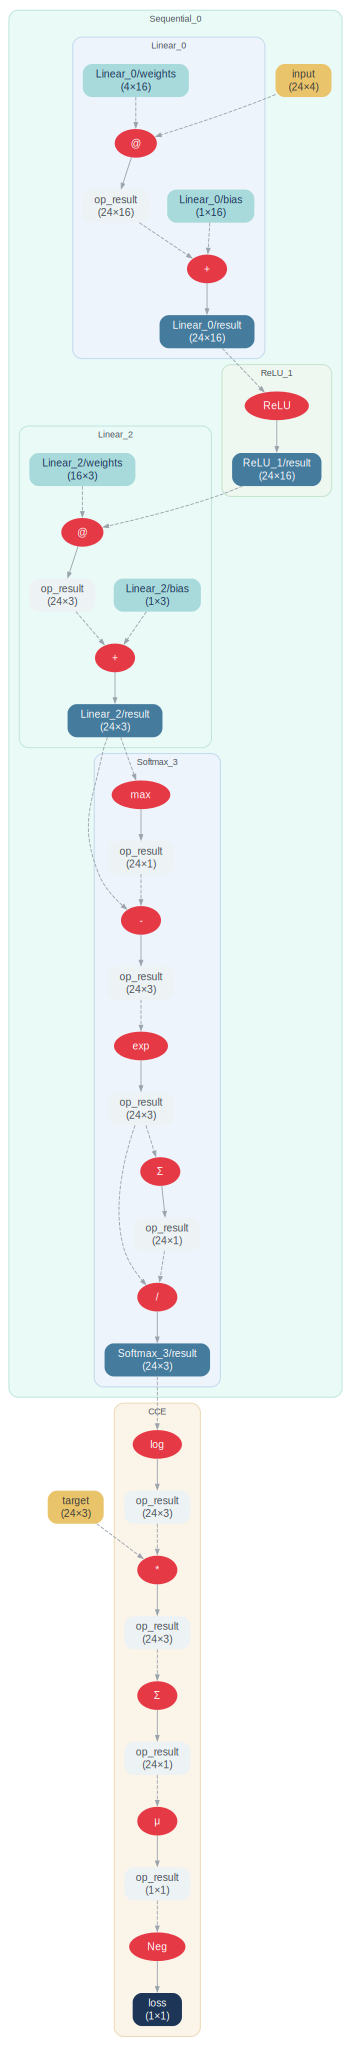

In [9]:
graph.draw_combined()

### Architecture

Each layer scope collapsed to a single box, with edges labelled by the shape of the tensor crossing between layers — the data-shape story of the whole network at a glance.

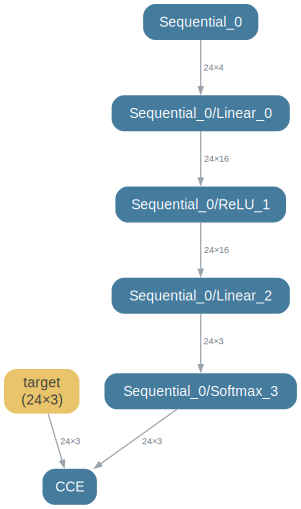

In [10]:
graph.draw_architecture()

## Vanishing gradients

Stacking many layers makes a network harder to train. During backprop, a gradient travels from the loss all the way back to the first layer, and at every layer it is scaled by that layer's weights and by the slope of its activation. With small weights and a **saturating** activation, that per-layer factor is well below 1 — so the signal reaching the earliest layers shrinks geometrically with depth, and they barely learn. This is the **vanishing gradient** problem.

To see it clearly we deliberately stack the deck: a deep `Linear + Sigmoid` network (sigmoid's slope is at most 0.25, and near its flat tails much less) initialized with naive small weights (`Uniform`, ±0.1). We run one forward/backward and read off the mean absolute weight-gradient of each `Linear` layer, input → output.

The two helpers below (`deep_stack`, `layer_grad_magnitudes`) are reused by the fix sections that follow, so each later experiment is a one-line change.

In [11]:
W, depth = 16, 8


def deep_stack(init, batchnorm=False):
    """A deep Sigmoid classifier built from one initializer.

    Optionally inserts BatchNorm before each activation. Returns a Model
    wrapping a Sequential with `depth` + 2 Linear layers (input projection,
    depth hidden blocks, head). Wrapping in Model stamps each layer with an
    indexed name, which the gradient-magnitude plots use as their x-axis.
    """

    def block(in_dim, out_dim):
        layers = [Linear(in_dim, out_dim, init)]
        if batchnorm:
            layers.append(BatchNorm(out_dim))
        layers.append(Sigmoid())
        return layers

    layers = block(4, W)
    for _ in range(depth):
        layers += block(W, W)
    layers += [Linear(W, 3, init), Softmax()]
    return Model(Sequential(layers))


def layer_grad_magnitudes(model):
    """Mean |weight gradient| of each Linear layer, input -> output."""
    magnitudes = []
    for layer in model.root.layers:
        if isinstance(layer, Linear):
            grads = layer.weights.grad
            label = layer.name.split("/")[-1]
            magnitudes.append((label, sum(abs(g) for g in grads) / len(grads)))
    return magnitudes


# naive baseline: tiny uniform weights feeding saturating sigmoids
naive = deep_stack(Uniform)
CCE().forward(y, naive.forward(x)).backward()
naive_mags = layer_grad_magnitudes(naive)
naive_mags

[('Linear_0', 2.216840692747376e-12),
 ('Linear_2', 2.8825573732155855e-12),
 ('Linear_4', 4.1470432362110466e-11),
 ('Linear_6', 5.64642726262304e-10),
 ('Linear_8', 7.926808634907453e-09),
 ('Linear_10', 9.915167174868282e-08),
 ('Linear_12', 1.663185646335224e-06),
 ('Linear_14', 2.3329681305313737e-05),
 ('Linear_16', 0.00045026556222858854),
 ('Linear_18', 0.015315857323249709)]

Plotted on a log axis, the gradient magnitude collapses by orders of magnitude as we move back toward the input. The plotting helper below takes a list of `(label, magnitudes)` series so the fix sections can overlay their curves on top of this baseline.

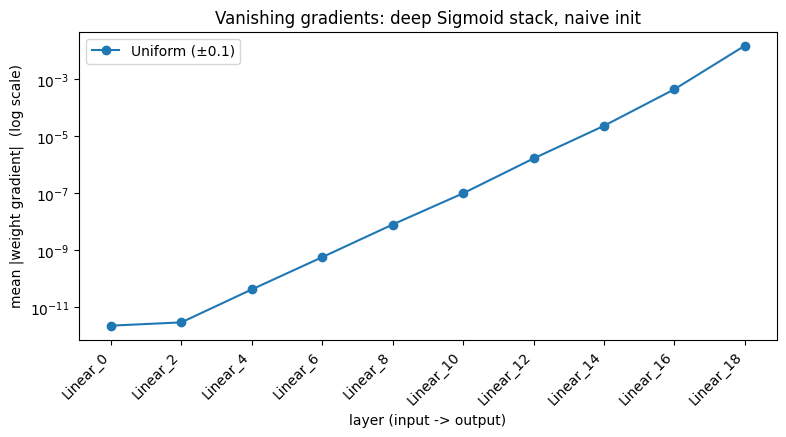

In [12]:
import matplotlib.pyplot as plt


def plot_magnitudes(series, title):
    """Overlay one log-scale gradient-magnitude curve per (label, magnitudes)."""
    names = [name for name, _ in series[0][1]]
    fig, ax = plt.subplots(figsize=(9, 4))
    for label, magnitudes in series:
        ax.plot(
            range(len(magnitudes)),
            [m for _, m in magnitudes],
            marker="o",
            label=label,
        )
    ax.set_yscale("log")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_xlabel("layer (input -> output)")
    ax.set_ylabel("mean |weight gradient|  (log scale)")
    ax.set_title(title)
    ax.legend()
    plt.show()


plot_magnitudes(
    [("Uniform (±0.1)", naive_mags)],
    "Vanishing gradients: deep Sigmoid stack, naive init",
)

Read left (input) to right (output): the early layers receive a gradient many orders of magnitude smaller than the last layer's, so they learn far more slowly — if at all. The two sections below attack this from different angles on the **same network**.

## Weight initialization

The first lever is the *scale of the initial weights*. `Uniform` ignores layer size and uses a fixed ±0.1, so signal shrinks as it passes through each layer. **Glorot** (Xavier) instead sizes the range from the layer's fan-in + fan-out, keeping the variance of activations — and therefore of gradients — roughly constant across depth.

Rebuild the *same* deep Sigmoid network with `Glorot` and overlay it on the naive baseline.

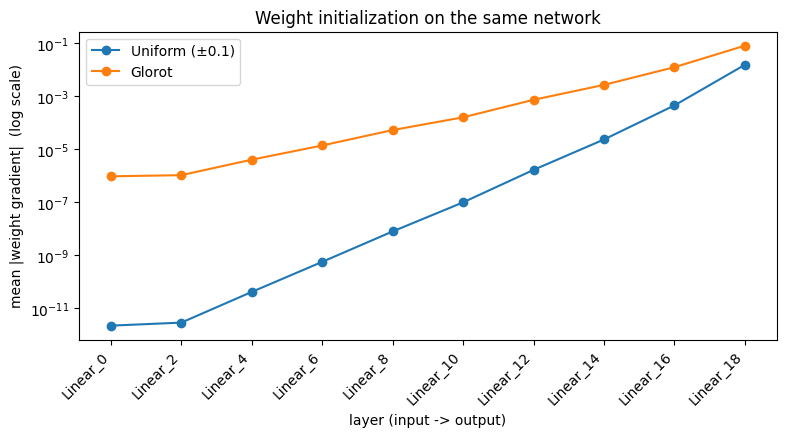

In [13]:
glorot = deep_stack(Glorot)
CCE().forward(y, glorot.forward(x)).backward()
glorot_mags = layer_grad_magnitudes(glorot)

plot_magnitudes(
    [("Uniform (±0.1)", naive_mags), ("Glorot", glorot_mags)],
    "Weight initialization on the same network",
)

Glorot lifts the input-layer gradient by several orders of magnitude — the early layers now receive a trainable signal instead of numerical noise. Note it doesn't *flatten* the curve completely: a deep stack of saturating sigmoids still decays somewhat from output to input. Initialization buys depth; it doesn't make depth free. That residual decay is what the next tool, and residual connections in Phase 6, address.

## Batch normalization

Initialization fixes the starting weights, but as training proceeds each layer's input distribution drifts (its mean and variance shift every batch), and saturating activations can slide back toward their flat regions. **Batch normalization** re-centres and re-scales every layer's pre-activation to zero mean / unit variance *per batch*, then lets the network rescale via learned `gamma`/`beta`. Because the input to each sigmoid is kept in its responsive range, the per-layer gradient factor stays near 1 regardless of how the weights were initialized.

Keep the **naive `Uniform` init** — the one that collapsed — but insert `BatchNorm` before each activation, and compare against that same baseline.

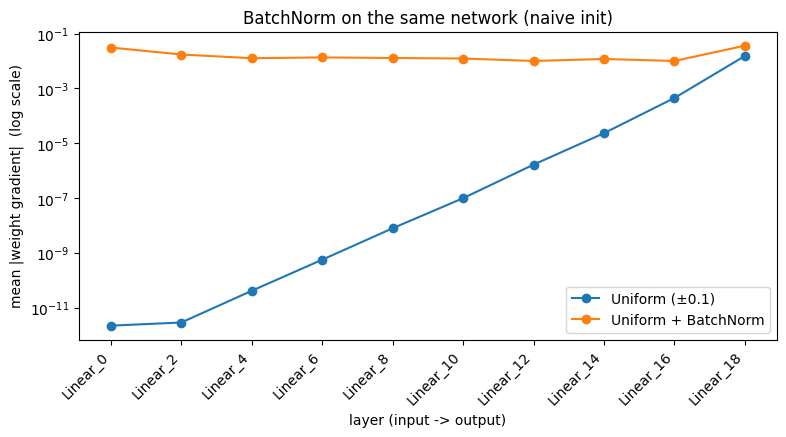

In [14]:
normed = deep_stack(Uniform, batchnorm=True)
CCE().forward(y, normed.forward(x)).backward()
normed_mags = layer_grad_magnitudes(normed)

plot_magnitudes(
    [("Uniform (±0.1)", naive_mags), ("Uniform + BatchNorm", normed_mags)],
    "BatchNorm on the same network (naive init)",
)

With BatchNorm the curve is essentially **flat**: even from the same tiny `Uniform` weights that collapsed to numerical noise, every layer — input to output — now receives a gradient of comparable magnitude. Normalization decouples trainability from the initial weight scale, which is what makes genuinely deep networks practical and sets up the residual blocks of Phase 6.